In [1]:
import datetime as dt
from decimal import Decimal

import pandas as pd

from TETrading.trading_system.trading_system import TradingSystem
from TETrading.position.position import Position
from TETrading.position.position_sizer.ext_position_sizer import ExtPositionSizer
from TETrading.plots.candlestick_plots import candlestick_plot

from data.api_data_utils.db_functions import get_db_conn, get_omxs_stock_data

Inside the 'strategy_function' the data (a Pandas DataFrame) is iterated over. Inside the loop, functions with entry and exit logic will be called and Position objects created
and yielded.

In [2]:
def strategy_function(df, entry_logic_func, exit_logic_func, entry_args=None, exit_args=None, signal_handler=None,
                      fixed_position_size=True, capital=100000, commission_pct_cost=0.0, generate_signals=False,
                      symbol='', plot_positions=False, save_position_figs_path=None):
    """
    Generates positions using given entry and exit logic functions,
    if generate_signals is True signals will be generated from the
    most recent data.

    Parameters
    ----------
    :param df:
        'Pandas Dataframe' : Data used by the trading system.
    :param entry_logic_func:
        'function' : A function with entry logic.
    :param exit_logic_func:
        'function' : A function with exit logic.
    :param entry_args:
        Keyword arg 'None/Dict' : Parameters used with the entry logic.
        Default value=None
    :param exit_args:
        Keyword arg 'None/Dict' : Parameters used with the exit logic.
        Default value=None
    :param signal_handler:
        Keyword arg 'None/SignalHandler' : SignalHandler object that
        handles data from generated market events/signals.
        Default value=None
    :param fixed_position_size:
        Keyword arg 'Boolean' : True/False decides whether the capital
        used for positions generated should be at a fixed amount or not.
        Default value=True
    :param capital:
        Keyword arg 'int/float' : The starting capital given to invest in
        the trading system.
        Default value=100000
    :param commission_pct_cost:
        Keyword arg 'float' : The transaction cost given as a percentage
        (a float from 0.0 to 1.0) of the total transaction.
        Default value=0.0
    :param generate_signals:
        Keyword arg 'Boolean' : True/False decides whether or not market
        events/signals should be generated from the most recent data.
        Default value=False
    :param symbol:
        Keyword arg 'str' : The ticker/symbol of the instrument which data
        has been provided to generate positions for.
        Default value=''
    :param plot_positions:
        Keyword arg 'Boolean' : True/False decides whether or not a plot of
        a candlestick chart visualizing the points of buying and selling a
        position should be displayed.
        Default value=False
    :param save_position_figs_path:
        Keyword arg 'None/str' : Provide a file path as a str to save a
        candlestick chart visualizing the points of buying and selling a
        position.
        Default value=None
    """

    # Instantiate a Position object
    position = Position(-1)
    direction = 'long'
    trailing_exit = False
    trailing_exit_price = None

    # apply indicators/features to dataframe
    df['SMA_50'] = df['Close'].rolling(50).mean()

    if isinstance(df.index, pd.DatetimeIndex):
        df.reset_index(level=0, inplace=True)

    for index, row in enumerate(df.itertuples()):
        # entry_args['entry_param_period'] is the parameter used with the longest period lookback required to calculate
        if index <= entry_args['entry_param_period']:
            continue

        if position and position.active_position is True:
            position.update(Decimal(df['Close'].iloc[index-1]))

            # call the exit logic function, passing required arguments
            exit_condition, trailing_exit, trailing_exit_price = exit_logic_func(
                df.iloc[index-exit_args['exit_param_period']:index], trailing_exit, trailing_exit_price,
                position.entry_price, exit_args, len(position.returns_list)
            )
            if exit_condition:
                capital = position.exit_market(row.Open, exit_signal_dt=df['Date'].iloc[index-1])
                position.print_position_stats()
                print(f'Exit index {index}: {format(row.Open, ".3f")}, {row.Date}\n'
                      f'Realised return: {position.position_return}')
                if plot_positions:
                    if save_position_figs_path is not None:
                        position_figs_path = save_position_figs_path + (
                            fr'\{df.iloc[(index - len(position.returns_list))].Date.strftime("%Y-%m-%d")}.jpg'
                        )
                    else:
                        position_figs_path = save_position_figs_path
                    candlestick_plot(
                        df.iloc[(index-len(position.returns_list)-3):(index+3)],
                        position.entry_dt, position.entry_price,
                        row.Date, row.Open, save_fig_to_path=position_figs_path
                    )
                yield position
            continue

        # Instantiate a Position object if the position.active_position field is False
        # and a call to entry_logic_func returns True
        if not position.active_position and entry_logic_func(
                df.iloc[(index-entry_args['entry_param_period']):index], entry_args
        ):
            position = Position(capital, fixed_position_size, commission_pct_cost=commission_pct_cost)
            position.enter_market(row.Open, direction, entry_dt=row.Date)
            print(f'\nEntry index {index}: {format(row.Open, ".3f")}, {row.Date}')

    # Handle the trading systems' current market events/signals
    if position.active_position and generate_signals:
        position.update(Decimal(df['Close'].iloc[-1]))
        position.print_position_status()
        signal_handler.handle_active_position(
            symbol, {'Signal_index': len(df), 'Signal_dt': df['Date'].iloc[-1], 'Ticker': symbol,
                     'Periods_in_position': len(position.returns_list), 'Unrealised return': position.unrealised_return}
        )
        exit_condition, trailing_exit_price, trailing_exit = exit_logic_func(
            df.iloc[-exit_args['exit_param_period']:], trailing_exit, trailing_exit_price,
            position.entry_price, exit_args, len(position.returns_list), position.unrealised_return
        )
        if exit_condition:
            signal_handler.handle_exit_signal(
                symbol, {'Signal_index': len(df), 'Signal_dt': df['Date'].iloc[-1], 'Ticker': symbol,
                         'Periods_in_position': len(position.returns_list),
                         'Unrealised return': position.unrealised_return}
            )
            print(f'\nExit signal, exit next open\nIndex {len(df)}')

    elif entry_logic_func(df.iloc[-entry_args['entry_param_period']:], entry_args) and generate_signals:
        signal_handler.handle_entry_signal(
            symbol, {'Signal_index': len(df), 'Signal_dt': df['Date'].iloc[-1], 'Ticker': symbol}
        )
        print(f'\nEntry signal, buy next open\nIndex {len(df)}')

Functions with logic for when to enter and exit a position in a market.

In [3]:
def entry_logic_test(df, *args):
    """
    An example of an entry logic function. Returns True/False
    depending on if the last value in the column 'Close' in the
    given Pandas DataFrame is the highest value in the column.

    Parameters
    ----------
    :param df:
        'Pandas DataFrame' : A slice of a Pandas DataFrame.
    :param args:
        'Tuple' : A tuple with parameters used with the entry logic.
    :return:
        'Boolean' : True/False depending on if the entry logic
        condition is met or not.
    """

    return df['Close'].iloc[-1] >= max(df['Close'].iloc[:])


def exit_logic_test(df, trail, trailing_exit_price, *args):
    """
    An example of an exit logic function. Returns True/False
    depending on if the last value in the column 'Close' in the
    given Pandas DataFrame is the lowest value in the column.

    Parameters
    ----------
    :param df:
        'Pandas DataFrame' : A slice of a Pandas DataFrame.
    :param trail:
        'Boolean' : Additional conditions can be used to
        activate a mechanism for using trailing exit logic.
    :param trailing_exit_price:
        'float/Decimal' : Upon activating a trailing exit
        mechanism, this variable could for example be given
        a price to use as a limit for returning the exit
        condition as True if the last price would fall below it.
    :param args:
        'Tuple' : A tuple with parameters used with the exit logic.
    :return:
        'Boolean' : True/False depending on if the exit logic
        condition is met or not.
    """

    return df['Close'].iloc[-1] <= min(df['Close'].iloc[:]), trail, trailing_exit_price

Declare a list with tickers/symbols of assets to get data for.

In [4]:
ticker_list = ['ATCO_A', 'ERIC_B', 'VOLV_B', 'EVO']

Declare variables with a start and end date and get data from an API, a database, CSV-files or any other source from where the data can be read into Pandas DataFrame objects. The data is held in a dict with the ticker/symbol as key and the data as the value:
{'Ticker1': Pandas.DataFrame, 'Ticker2': Pandas.DataFrame}.

In [5]:
start_date = dt.datetime(2020, 1, 1)
end_date = dt.datetime(2021, 1, 1)

connection, cursor = get_db_conn('omxs_price_data_b')
df_dict = {ticker: get_omxs_stock_data(ticker, connection, cursor, start_date=start_date, end_date=end_date)
            for ticker in ticker_list}

for ticker, data in dict(df_dict).items():
    if data.empty:
        print(f'Empty DataFrame: {ticker}')
        del df_dict[ticker]

Create an object of a class derived from the PositionSizer class. The class should implement functionality for sizing positions. If functionality for position sizing is to be handled outside of the TradingSystem, an instance of the ExtPositionSizer class can be provided.

In [6]:
pos_sizer = ExtPositionSizer('Sharpe ratio')

Create an instance of TradingSystem, pass it the necessary parameters and run it by calling it.


Entry index 27: 366.100, 2020-02-11 00:00:00
Unrealised P/L sequence: [8.7, 12.4, 10.2, 10.3, 7.6, 1.3, 5.2, 2.1, -7.4, -16.0]
Market to market returns: [2.38, 0.99, -0.58, 0.03, -0.72, -1.69, 1.06, -0.83, -2.58, -2.4]
Unrealised return sequence: [2.38, 3.39, 2.79, 2.81, 2.08, 0.36, 1.42, 0.57, -2.02, -4.37]
Exit index 36: 350.100, 2020-02-24 00:00:00
Realised return: -4.37


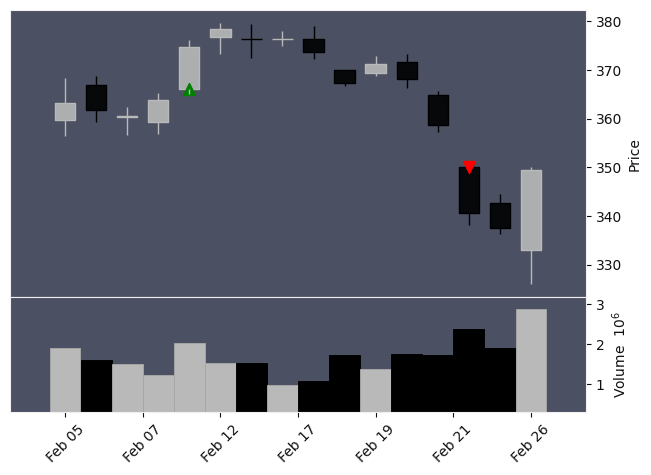


Entry index 59: 309.300, 2020-03-26 00:00:00
Unrealised P/L sequence: [15.5, 5.6, 21.7, 24.6, 1.9, 4.7, 1.3, 15.4, 25.7, 22.2, 21.0, 33.7, 18.0, 28.4, 38.8, 37.6, 26.6, 41.3, 60.2, 35.7, 35.0, 37.3, 37.7, 30.0, 12.0, 17.4]
Market to market returns: [5.01, -3.05, 5.11, 0.88, -6.8, 0.9, -1.08, 4.54, 3.17, -1.04, -0.36, 3.84, -4.58, 3.18, 3.08, -0.34, -3.17, 4.38, 5.39, -6.63, -0.2, 0.67, 0.12, -2.22, -5.31, 1.68]
Unrealised return sequence: [5.01, 1.81, 7.02, 7.95, 0.61, 1.52, 0.42, 4.98, 8.31, 7.18, 6.79, 10.9, 5.82, 9.18, 12.54, 12.16, 8.6, 13.35, 19.46, 11.54, 11.32, 12.06, 12.19, 9.7, 3.88, 5.63]
Exit index 84: 326.700, 2020-05-05 00:00:00
Realised return: 5.63


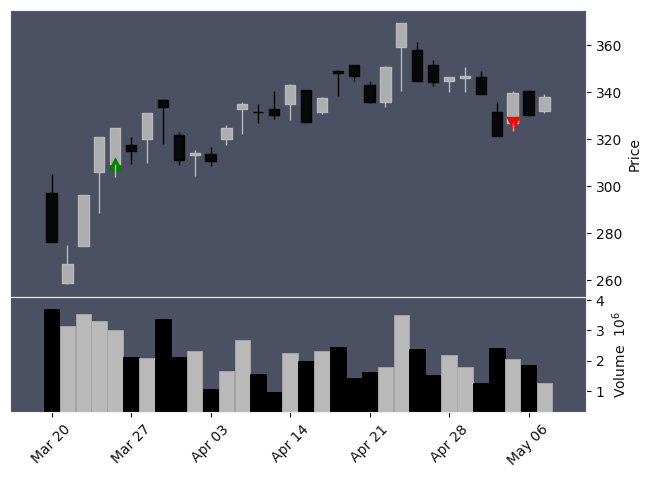


Entry index 90: 347.400, 2020-05-13 00:00:00
Unrealised P/L sequence: [-1.5, -12.5, -11.8, 11.2, 9.9, 12.4, 8.3, 16.1, 17.2, 18.2, 34.8, 21.8, 27.7, 22.9, 31.1, 28.8, 38.9, 31.0, 30.7, 32.2, 22.0, 24.2, 27.8, 39.2, 50.7, 46.6, 45.6, 55.0, 44.9, 45.2, 46.9, 48.1, 47.2, 47.8, 54.2, 52.5, 59.1, 56.5, 53.3, 54.1, 60.4, 65.3, 64.5, 80.6, 72.5, 62.1, 63.2, 58.7, 65.4, 64.0, 52.8, 51.6]
Market to market returns: [-0.43, -3.18, 0.21, 6.85, -0.36, 0.7, -1.14, 2.19, 0.3, 0.27, 4.54, -3.4, 1.6, -1.28, 2.21, -0.61, 2.68, -2.05, -0.08, 0.4, -2.69, 0.6, 0.97, 3.04, 2.97, -1.03, -0.25, 2.39, -2.51, 0.08, 0.43, 0.3, -0.23, 0.15, 1.62, -0.42, 1.65, -0.64, -0.79, 0.2, 1.57, 1.2, -0.19, 3.91, -1.89, -2.48, 0.27, -1.1, 1.65, -0.34, -2.72, -0.3]
Unrealised return sequence: [-0.43, -3.6, -3.4, 3.22, 2.85, 3.57, 2.39, 4.63, 4.95, 5.24, 10.02, 6.28, 7.97, 6.59, 8.95, 8.29, 11.2, 8.92, 8.84, 9.27, 6.33, 6.97, 8.0, 11.28, 14.59, 13.41, 13.13, 15.83, 12.92, 13.01, 13.5, 13.85, 13.59, 13.76, 15.6, 15.11, 17.01, 

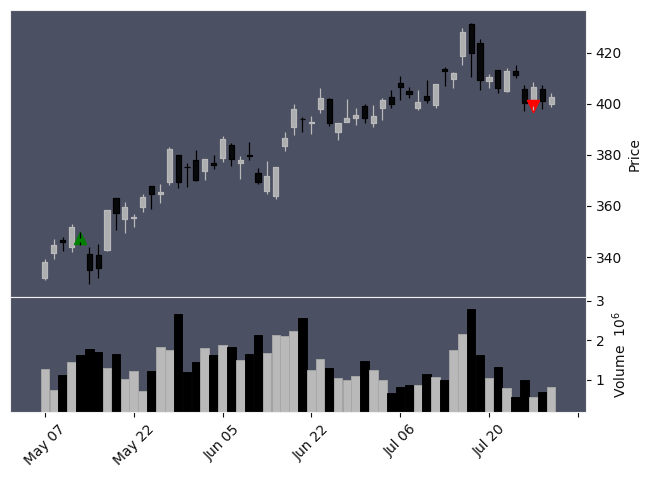


Entry index 153: 403.900, 2020-08-12 00:00:00
Unrealised P/L sequence: [-2.9, 0.1, -11.3, -4.5, -8.7, -5.4, -12.3, -12.4]
Market to market returns: [-0.72, 0.75, -2.82, 1.73, -1.05, 0.84, -1.73, -0.03]
Unrealised return sequence: [-0.72, 0.02, -2.8, -1.11, -2.15, -1.34, -3.05, -3.07]
Exit index 160: 391.500, 2020-08-21 00:00:00
Realised return: -3.07


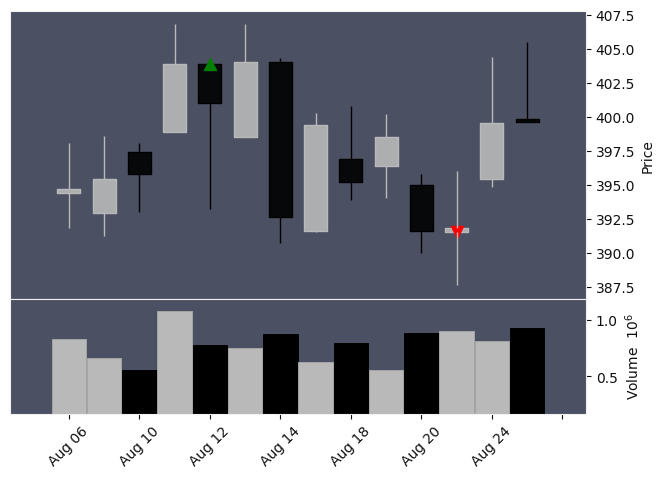


Entry index 165: 403.000, 2020-08-28 00:00:00
Unrealised P/L sequence: [-6.5, -3.1, -2.9, 2.0, -6.2, -5.4, 5.4, -1.8, 7.4, 5.9, 6.2, 6.7, 8.9, 13.2, 14.7, 22.6, 7.0, 11.1, 17.9, 10.5, 16.2, 33.7, 35.6, 25.8, 26.1, 17.2, 25.4, 20.6, 20.9, 19.8, 24.1, 30.3, 28.0, 24.7, 13.6, 15.5]
Market to market returns: [-1.61, 0.86, 0.05, 1.22, -2.02, 0.2, 2.72, -1.76, 2.29, -0.37, 0.07, 0.12, 0.54, 1.04, 0.36, 1.89, -3.67, 1.0, 1.64, -1.76, 1.38, 4.17, 0.44, -2.23, 0.07, -2.07, 1.95, -1.12, 0.07, -0.26, 1.02, 1.45, -0.53, -0.77, -2.6, 0.46]
Unrealised return sequence: [-1.61, -0.77, -0.72, 0.5, -1.54, -1.34, 1.34, -0.45, 1.84, 1.46, 1.54, 1.66, 2.21, 3.28, 3.65, 5.61, 1.74, 2.75, 4.44, 2.61, 4.02, 8.36, 8.83, 6.4, 6.48, 4.27, 6.3, 5.11, 5.19, 4.91, 5.98, 7.52, 6.95, 6.13, 3.37, 3.85]
Exit index 200: 418.500, 2020-10-16 00:00:00
Realised return: 3.85


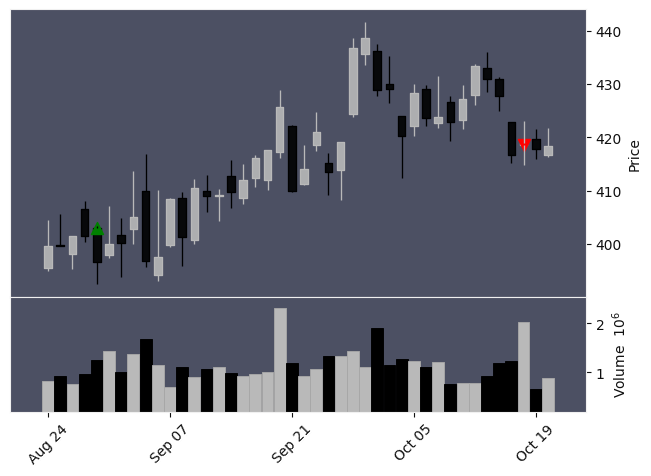


Entry index 214: 411.300, 2020-11-05 00:00:00
Unrealised P/L sequence: [5.1, 6.3, 22.4, 9.8, 20.9, 19.5, 24.4, 24.6, 27.1, 27.4, 29.3, 33.7, 32.9, 29.6, 29.7, 26.4, 28.4, 20.9, 22.1]
Market to market returns: [1.24, 0.29, 3.86, -2.91, 2.64, -0.32, 1.14, 0.05, 0.57, 0.07, 0.43, 1.0, -0.18, -0.74, 0.02, -0.75, 0.46, -1.71, 0.28]
Unrealised return sequence: [1.24, 1.53, 5.45, 2.38, 5.08, 4.74, 5.93, 5.98, 6.59, 6.66, 7.12, 8.19, 8.0, 7.2, 7.22, 6.42, 6.9, 5.08, 5.37]
Exit index 232: 433.400, 2020-12-01 00:00:00
Realised return: 5.37


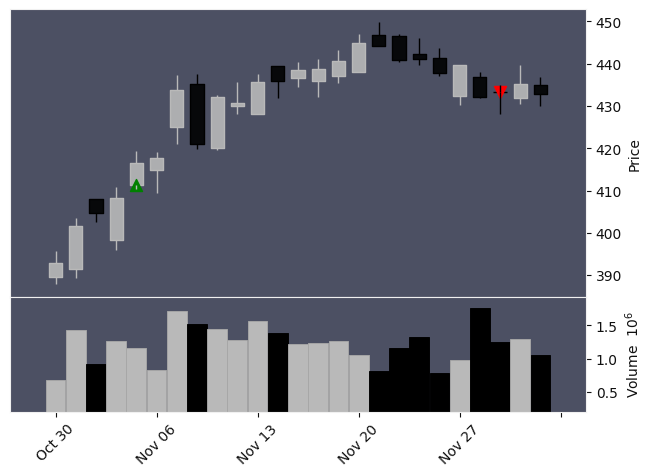


Entry index 238: 448.200, 2020-12-09 00:00:00
Unrealised P/L sequence: [-2.7, -19.1, -20.8]
Market to market returns: [-0.6, -3.68, -0.4]
Unrealised return sequence: [-0.6, -4.26, -4.64]
Exit index 240: 427.400, 2020-12-11 00:00:00
Realised return: -4.64


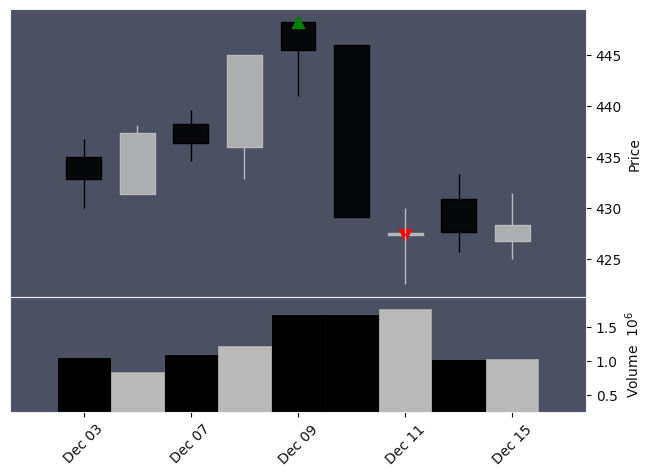


Ticker: ATCO_A
Performance summary: 
Number of positions: 7
Number of profitable positions: 4
Number of loosing positions: 3
% wins: 57.14
% losses: 42.86
Testing periods: 251
Start capital: 10000
Final capital: 12763.000
Total gross profit: 2763.000
Avg pos net profit: 245.257
Mean P/L: 8.200
Median P/L: 15.500
Std of P/L: 24.100
Mean return: 2.517
Median return: 3.850
Std of returns: 6.564
Expectancy: 22.257
Rate of return: 27.63
Max drawdown: 14.42%
RoMad: 1.916%
Profit factor: 1.490
CAGR: 27.63%
Sharpe ratio: 0.4427
Avg annual profit: 2763.00

Total equity market to market:
[10000.0, 10235.26, 10335.45, 10276.17, 10279.22, 10206.04, 10035.51, 10140.66, 10057.45, 9800.94, 9635.44, 10131.31, 9814.31, 10329.22, 10422.42, 9695.87, 9785.49, 9676.98, 10128.22, 10457.59, 10346.1, 10307.91, 10713.8, 10211.1, 10544.15, 10876.98, 10839.11, 10487.2, 10958.02, 11562.79, 10778.8, 10756.72, 10830.55, 10843.86, 10597.31, 10020.67, 10244.94, 10203.11, 9895.12, 9914.81, 10558.51, 10522.36, 10592.3

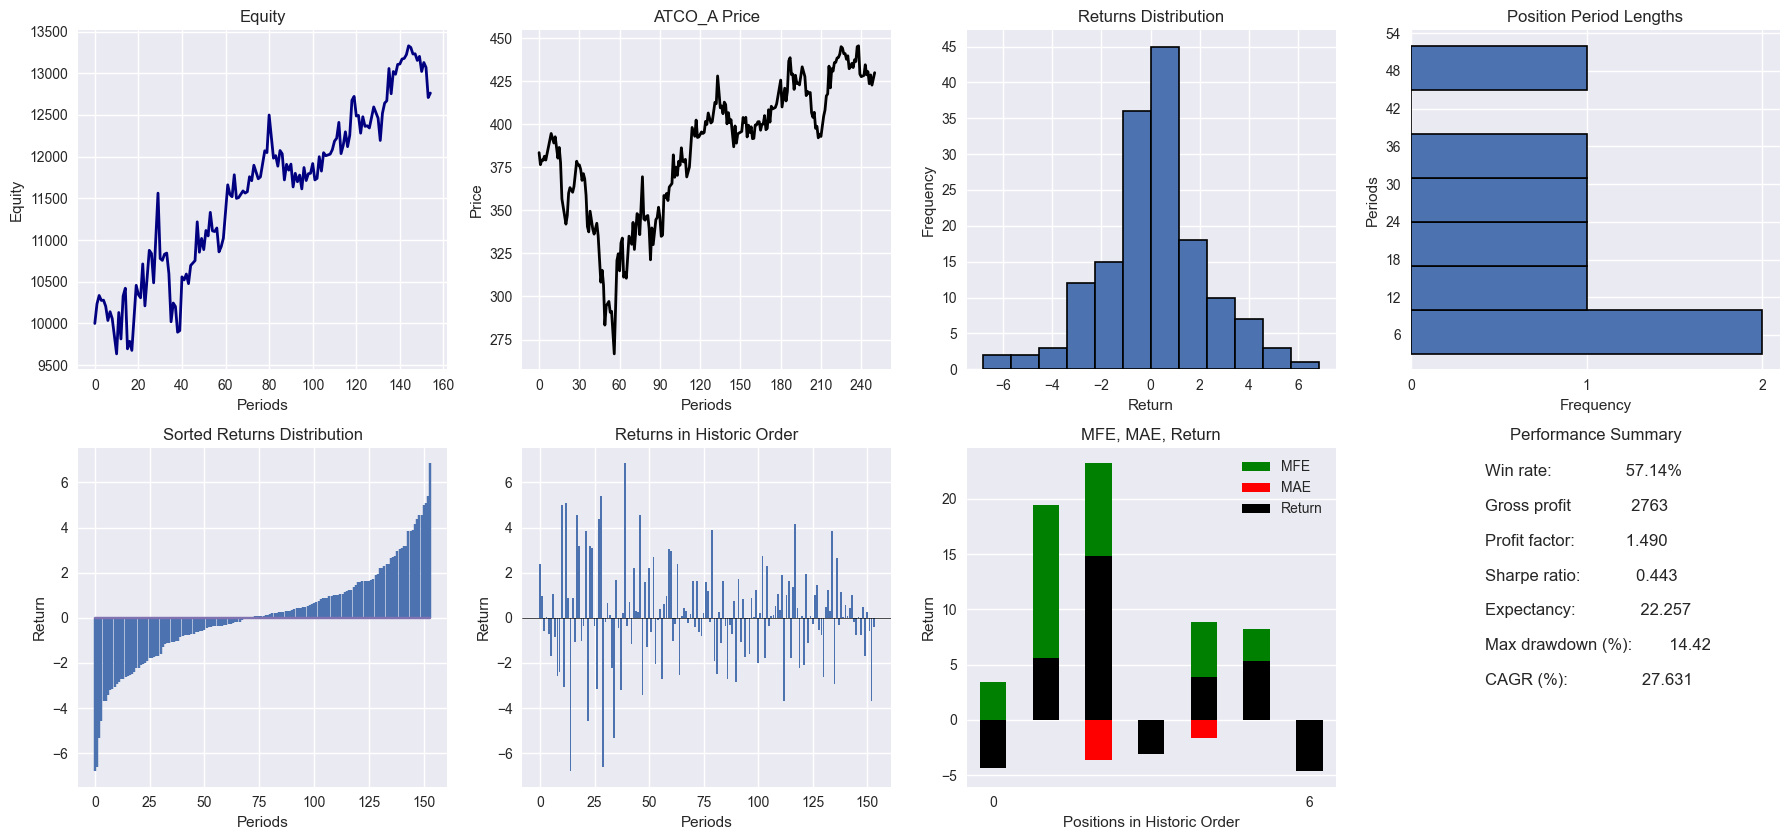


Running Monte Carlo simulations...


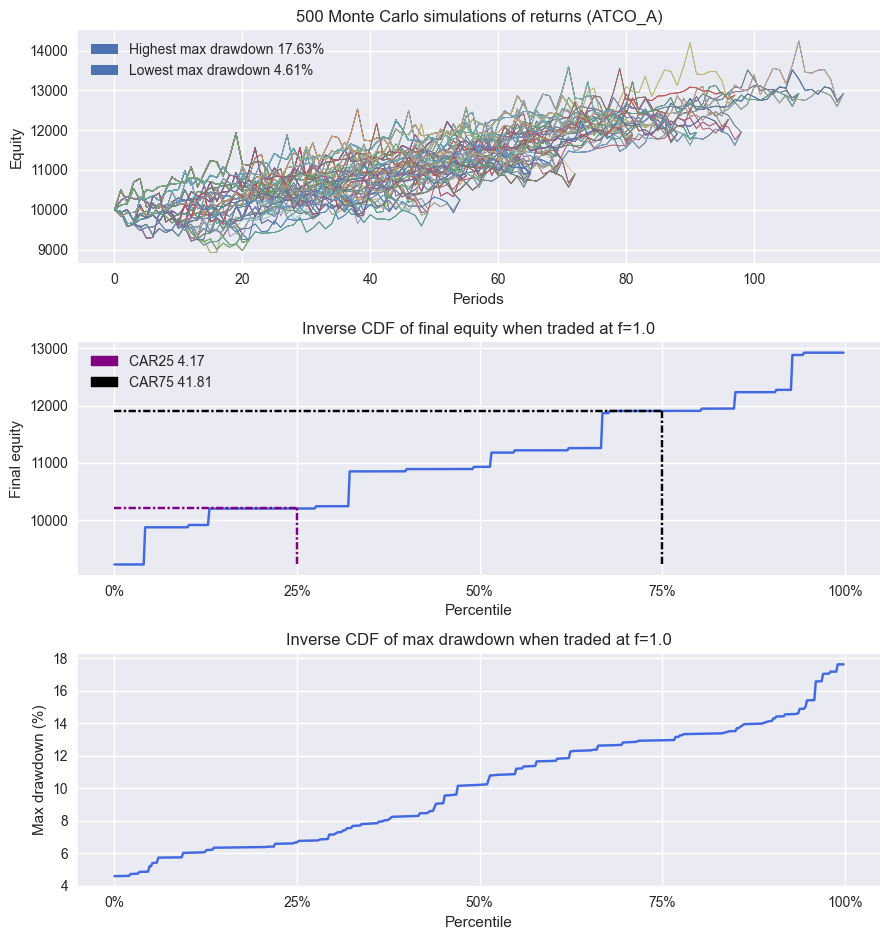


Entry index 26: 84.420, 2020-02-10 00:00:00
Unrealised P/L sequence: [-1.42, 3.96, 3.96, 3.96, 3.78, 3.7, 3.18, 3.7, 3.08, 2.32, -0.86, -0.82]
Market to market returns: [-1.68, 6.48, 0.0, 0.0, -0.2, -0.09, -0.59, 0.59, -0.7, -0.87, -3.67, 0.05]
Unrealised return sequence: [-1.68, 4.69, 4.69, 4.69, 4.48, 4.38, 3.77, 4.38, 3.65, 2.75, -1.02, -0.97]
Exit index 37: 83.600, 2020-02-25 00:00:00
Realised return: -0.97


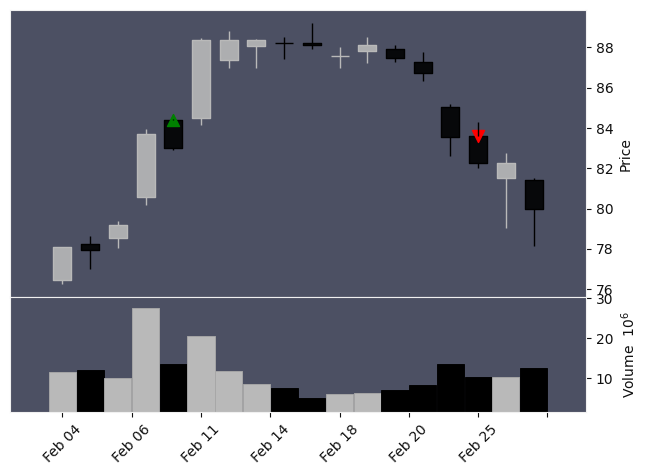


Entry index 55: 77.560, 2020-03-20 00:00:00
Unrealised P/L sequence: [-3.32, -7.0, -1.54, -0.86, -1.96, -3.8, 1.12, 3.5, 1.32, 1.64, 0.82, 2.2, 2.08, 3.32, 2.44, 4.84, 3.7, 6.16, 9.04, 8.7, 3.78, 7.66, 6.48, 3.54, 5.54, 4.62, 5.96, 7.54, 3.84, 4.88, 4.16, 4.72, 6.06, 6.16, 7.64, 4.68, 1.98, 1.98]
Market to market returns: [-4.28, -4.96, 7.74, 0.89, -1.43, -2.43, 6.67, 3.02, -2.69, 0.41, -1.04, 1.76, -0.15, 1.56, -1.09, 3.0, -1.38, 3.03, 3.44, -0.39, -5.7, 4.77, -1.38, -3.5, 2.47, -1.11, 1.63, 1.89, -4.35, 1.28, -0.87, 0.69, 1.63, 0.12, 1.77, -3.47, -3.28, 0.0]
Unrealised return sequence: [-4.28, -9.03, -1.99, -1.11, -2.53, -4.9, 1.44, 4.51, 1.7, 2.11, 1.06, 2.84, 2.68, 4.28, 3.15, 6.24, 4.77, 7.94, 11.66, 11.22, 4.87, 9.88, 8.35, 4.56, 7.14, 5.96, 7.68, 9.72, 4.95, 6.29, 5.36, 6.09, 7.81, 7.94, 9.85, 6.03, 2.55, 2.55]
Exit index 92: 79.540, 2020-05-15 00:00:00
Realised return: 2.55


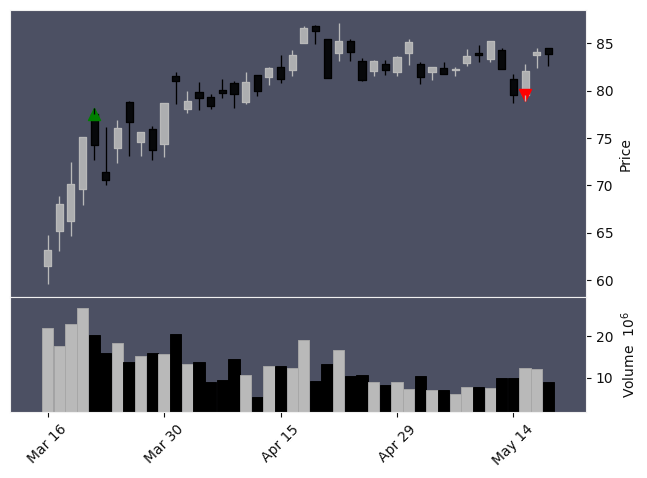


Entry index 97: 85.780, 2020-05-25 00:00:00
Unrealised P/L sequence: [1.26, -0.34, -1.66, 0.16, -0.14, 0.68, 1.66, 5.14, 3.26, 2.62, 0.84, -0.5, 0.82, -2.78, -3.78]
Market to market returns: [1.47, -1.84, -1.54, 2.16, -0.35, 0.96, 1.13, 3.98, -2.07, -0.72, -2.01, -1.55, 1.55, -4.16, -1.2]
Unrealised return sequence: [1.47, -0.4, -1.94, 0.19, -0.16, 0.79, 1.94, 5.99, 3.8, 3.05, 0.98, -0.58, 0.96, -3.24, -4.41]
Exit index 111: 82.000, 2020-06-12 00:00:00
Realised return: -4.41


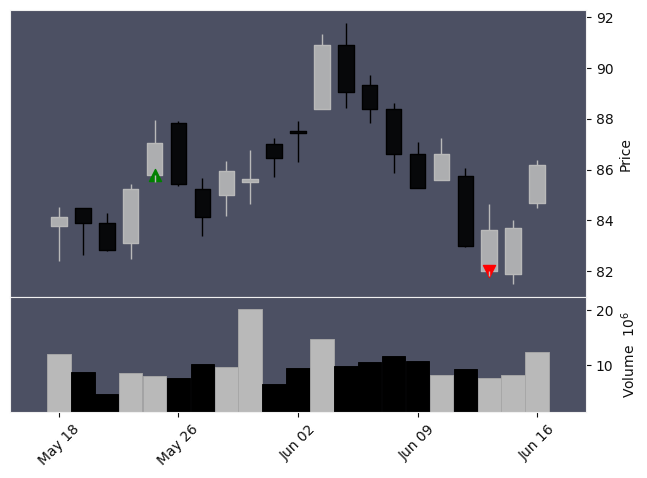


Entry index 125: 86.600, 2020-07-03 00:00:00
Unrealised P/L sequence: [0.56, 5.28, 1.94, 1.0, -1.12, -0.66]
Market to market returns: [0.65, 5.42, -3.64, -1.06, -2.42, 0.54]
Unrealised return sequence: [0.65, 6.1, 2.24, 1.15, -1.29, -0.76]
Exit index 130: 85.940, 2020-07-10 00:00:00
Realised return: -0.76


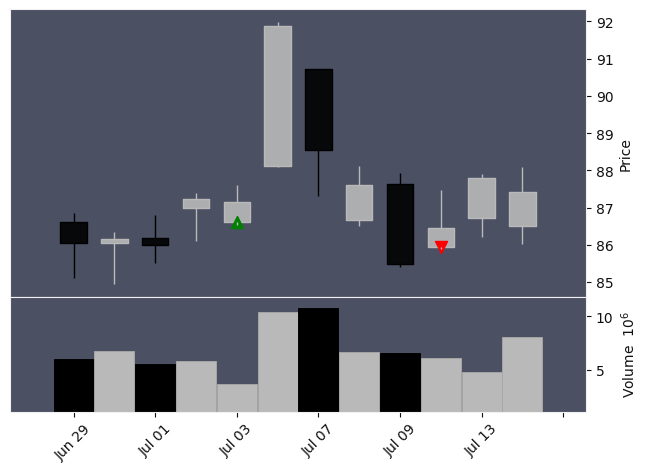


Entry index 136: 98.000, 2020-07-20 00:00:00
Unrealised P/L sequence: [4.7, 6.15, 5.6, 6.4, 2.65, 3.9, 3.0, 3.1, 1.02, 2.8, 4.6, 4.35, 3.2, 3.35, 3.55, 3.35, 4.1, 5.55, 4.95, 2.55, 2.55]
Market to market returns: [4.8, 1.41, -0.53, 0.77, -3.59, 1.24, -0.88, 0.1, -2.06, 1.8, 1.79, -0.24, -1.12, 0.15, 0.2, -0.2, 0.74, 1.42, -0.58, -2.33, 0.0]
Unrealised return sequence: [4.8, 6.28, 5.71, 6.53, 2.7, 3.98, 3.06, 3.16, 1.04, 2.86, 4.69, 4.44, 3.27, 3.42, 3.62, 3.42, 4.18, 5.66, 5.05, 2.6, 2.6]
Exit index 156: 100.550, 2020-08-17 00:00:00
Realised return: 2.60


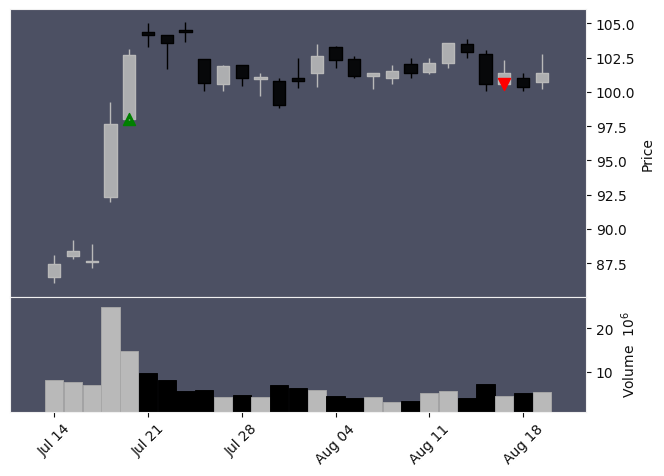


Entry index 164: 104.300, 2020-08-27 00:00:00
Unrealised P/L sequence: [0.1, -3.15, -4.05, -4.05, -3.8, -7.2, -7.2]
Market to market returns: [0.1, -3.11, -0.89, 0.0, 0.25, -3.38, 0.0]
Unrealised return sequence: [0.1, -3.02, -3.88, -3.88, -3.64, -6.9, -6.9]
Exit index 170: 97.100, 2020-09-04 00:00:00
Realised return: -6.90


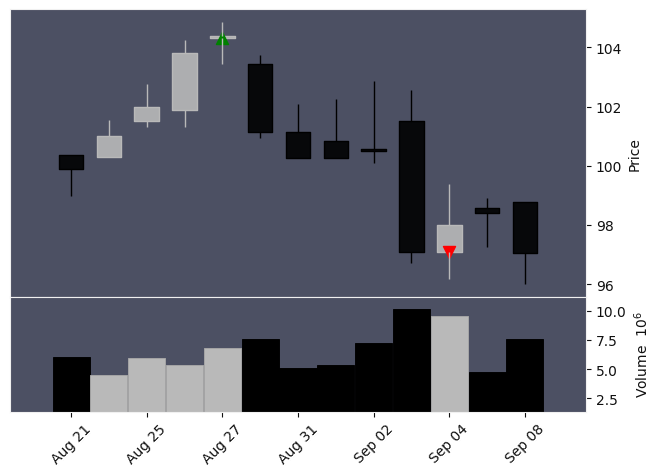


Entry index 189: 98.280, 2020-10-01 00:00:00
Unrealised P/L sequence: [-2.14, -3.3, -2.72, -2.3, -3.18, -2.58, -2.22, -2.36, -2.92, -2.48, -3.06, -3.28, -1.86]
Market to market returns: [-2.18, -1.21, 0.61, 0.44, -0.92, 0.63, 0.38, -0.15, -0.58, 0.46, -0.61, -0.23, 1.49]
Unrealised return sequence: [-2.18, -3.36, -2.77, -2.34, -3.24, -2.63, -2.26, -2.4, -2.97, -2.52, -3.11, -3.34, -1.89]
Exit index 201: 96.420, 2020-10-19 00:00:00
Realised return: -1.89


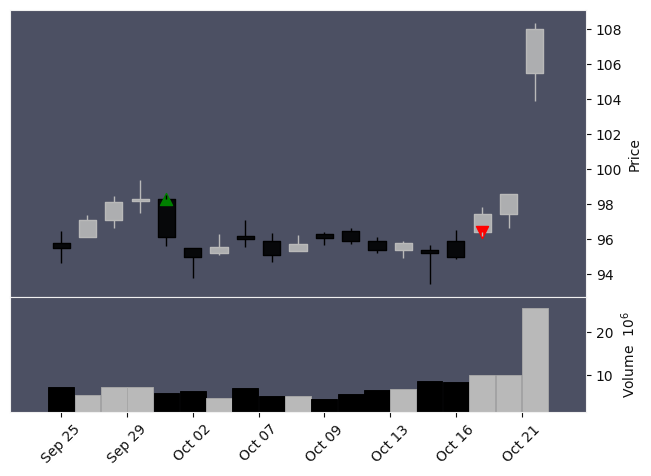


Entry index 202: 97.420, 2020-10-20 00:00:00
Unrealised P/L sequence: [1.14, 10.58, 11.58, 11.03, 7.83, 6.08, 3.23, 3.28, 1.86, 3.03, 4.18, 5.63, 7.68, 7.43, 9.43, 2.4, 4.93, 5.93, 5.33, 6.83, 6.88, 6.03, 6.93, 7.53, 6.23, 7.18, 6.83, 6.93, 8.73, 7.43, 7.73, 7.18, 6.63, 6.98, 7.38, 8.58, 8.08, 7.08, 2.63, 2.73]
Market to market returns: [1.17, 9.58, 0.93, -0.5, -2.95, -1.66, -2.75, 0.05, -1.41, 1.18, 1.14, 1.43, 1.99, -0.24, 1.91, -6.58, 2.53, 0.98, -0.58, 1.46, 0.05, -0.81, 0.87, 0.57, -1.24, 0.92, -0.33, 0.1, 1.72, -1.22, 0.29, -0.52, -0.53, 0.34, 0.38, 1.15, -0.47, -0.95, -4.26, 0.1]
Unrealised return sequence: [1.17, 10.86, 11.89, 11.32, 8.04, 6.24, 3.32, 3.37, 1.91, 3.11, 4.29, 5.78, 7.88, 7.63, 9.68, 2.46, 5.06, 6.09, 5.47, 7.01, 7.06, 6.19, 7.11, 7.73, 6.39, 7.37, 7.01, 7.11, 8.96, 7.63, 7.93, 7.37, 6.81, 7.16, 7.58, 8.81, 8.29, 7.27, 2.7, 2.8]
Exit index 241: 100.150, 2020-12-14 00:00:00
Realised return: 2.80


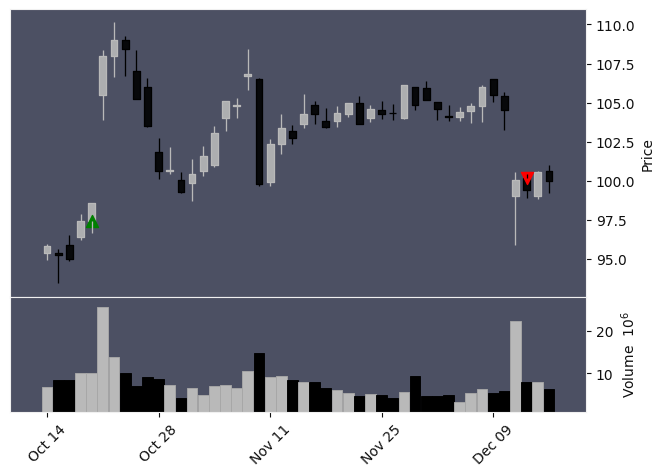


Ticker: ERIC_B
Performance summary: 
Number of positions: 8
Number of profitable positions: 3
Number of loosing positions: 5
% wins: 37.50
% losses: 62.50
Testing periods: 251
Start capital: 10000
Final capital: 9355.000
Total gross profit: -645.000
Avg pos net profit: -86.375
Mean P/L: -0.882
Median P/L: -0.740
Std of P/L: 3.208
Mean return: -0.873
Median return: -0.865
Std of returns: 3.301
Expectancy: 2.697
Rate of return: -6.45
Max drawdown: 19.53%
RoMad: -0.330%
Profit factor: 0.636
CAGR: -6.45%
Sharpe ratio: -0.3787
Avg annual profit: -645.00

Total equity market to market:
[10000.0, 9832.65, 10467.31, 10467.31, 10467.31, 10446.45, 10437.08, 10375.73, 10436.72, 10363.93, 10274.1, 9898.45, 9892.25, 9467.35, 8996.01, 9695.04, 9781.64, 9641.26, 9406.12, 10035.87, 10340.02, 10060.92, 10102.32, 9996.89, 10173.46, 10158.15, 10317.17, 10204.33, 10511.52, 10365.97, 10681.13, 11049.78, 11006.55, 10377.16, 10873.84, 10723.29, 10346.74, 10603.18, 10485.09, 10656.57, 10858.65, 10384.76, 105

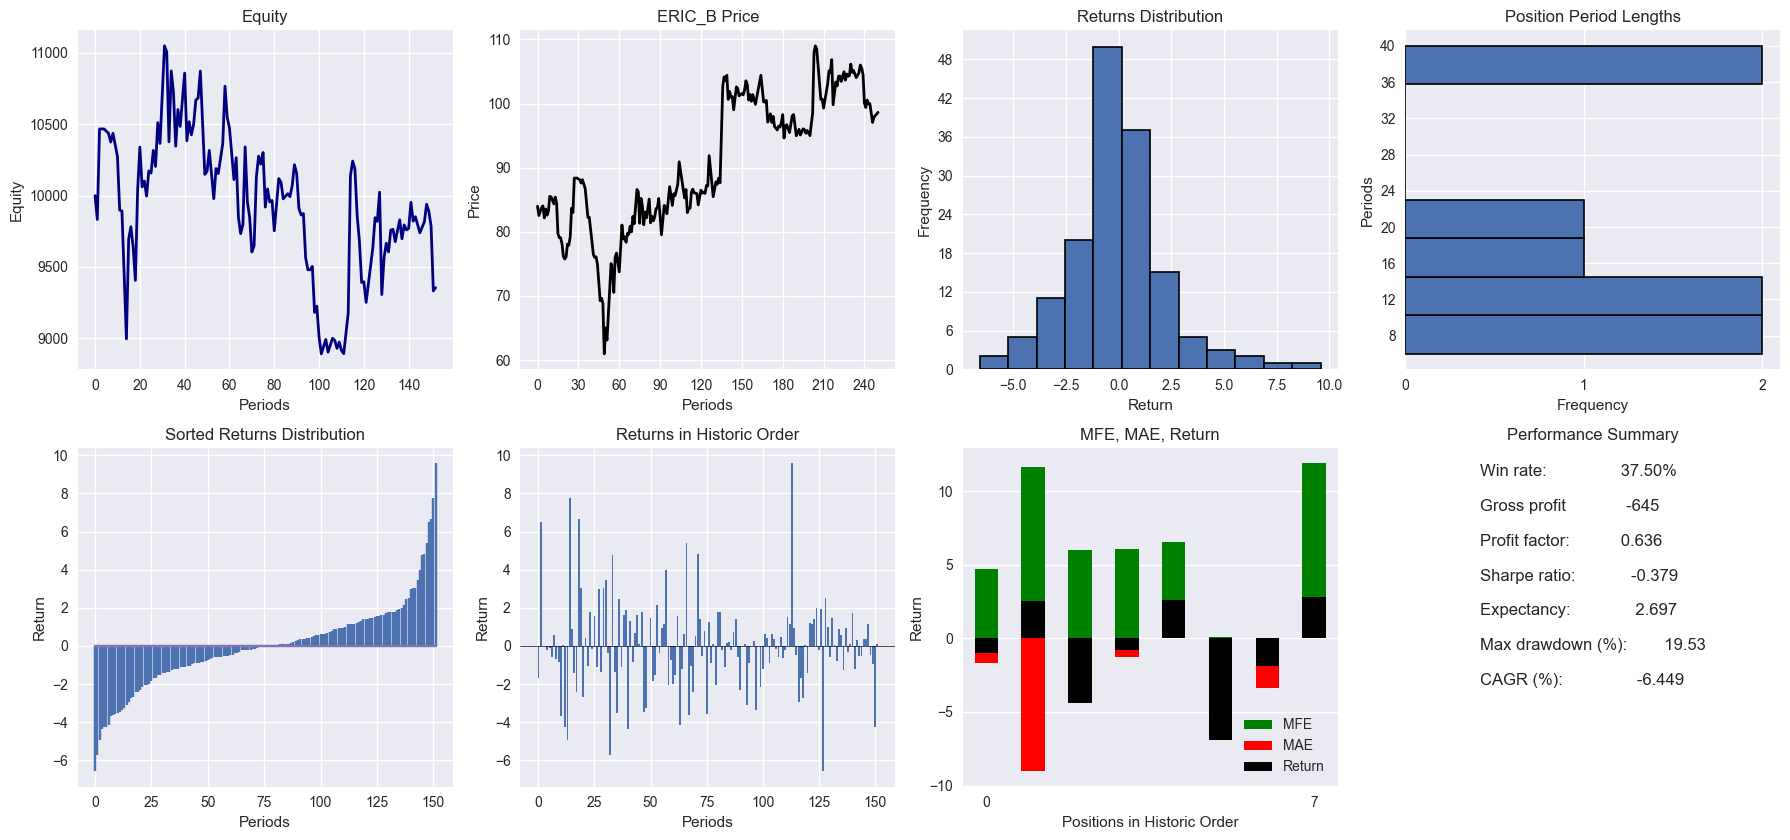


Running Monte Carlo simulations...


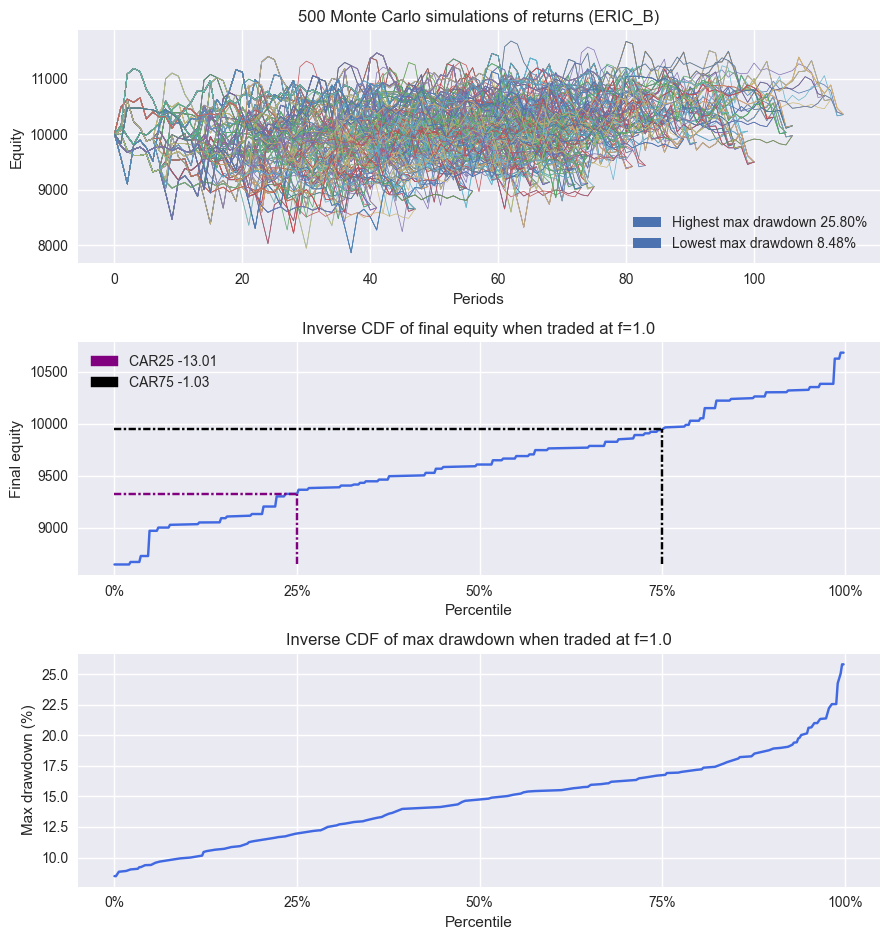


Entry index 12: 160.000, 2020-01-21 00:00:00
Unrealised P/L sequence: [1.45, -1.9, -4.8, -3.35]
Market to market returns: [0.91, -2.07, -1.83, 0.93]
Unrealised return sequence: [0.91, -1.19, -3.0, -2.09]
Exit index 15: 156.650, 2020-01-24 00:00:00
Realised return: -2.09


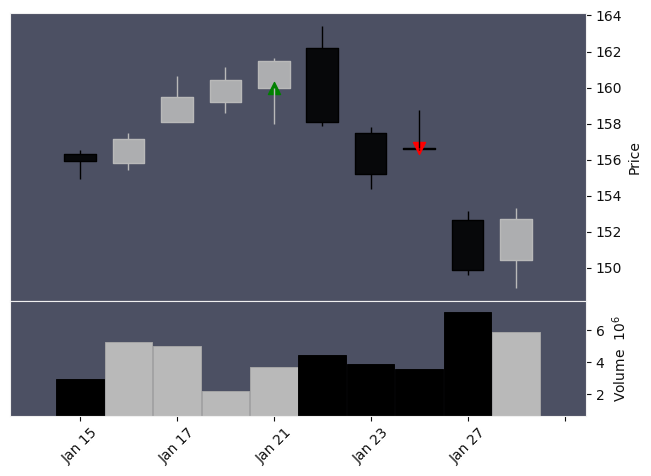


Entry index 20: 166.050, 2020-01-31 00:00:00
Unrealised P/L sequence: [-0.75, 0.45, 5.35, 6.7, 4.4, 4.4, 6.85, 7.05, 7.2, 6.75, 7.3, 7.35, 6.25, 5.65, 7.4, 4.65, -0.3]
Market to market returns: [-0.45, 0.73, 2.94, 0.79, -1.33, 0.0, 1.44, 0.12, 0.09, -0.26, 0.32, 0.03, -0.63, -0.35, 1.02, -1.59, -2.9]
Unrealised return sequence: [-0.45, 0.27, 3.22, 4.03, 2.65, 2.65, 4.13, 4.25, 4.34, 4.07, 4.4, 4.43, 3.76, 3.4, 4.46, 2.8, -0.18]
Exit index 36: 165.750, 2020-02-24 00:00:00
Realised return: -0.18


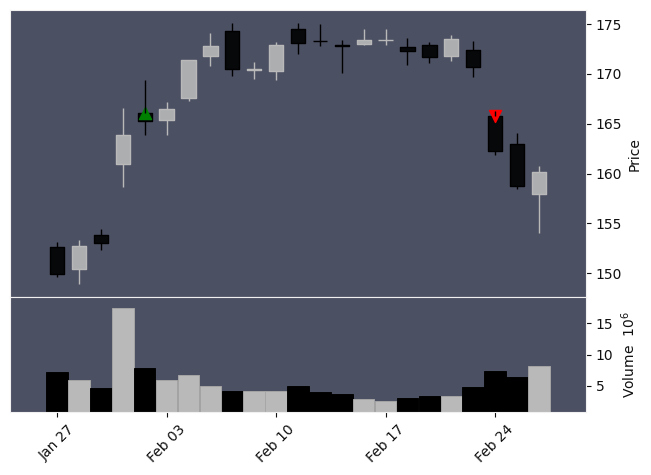


Entry index 63: 116.000, 2020-04-01 00:00:00
Unrealised P/L sequence: [-3.15, -1.05, -3.9, 5.0, 12.5, 10.1, 11.0, 9.65, 1.6, 3.35, 8.4, 9.05, 4.7, 10.4, 3.7, 0.2, 1.85]
Market to market returns: [-2.72, 1.86, -2.48, 7.94, 6.2, -1.87, 0.71, -1.06, -6.41, 1.49, 4.23, 0.52, -3.48, 4.72, -5.3, -2.92, 1.42]
Unrealised return sequence: [-2.72, -0.91, -3.36, 4.31, 10.78, 8.71, 9.48, 8.32, 1.38, 2.89, 7.24, 7.8, 4.05, 8.97, 3.19, 0.17, 1.59]
Exit index 79: 117.850, 2020-04-27 00:00:00
Realised return: 1.59


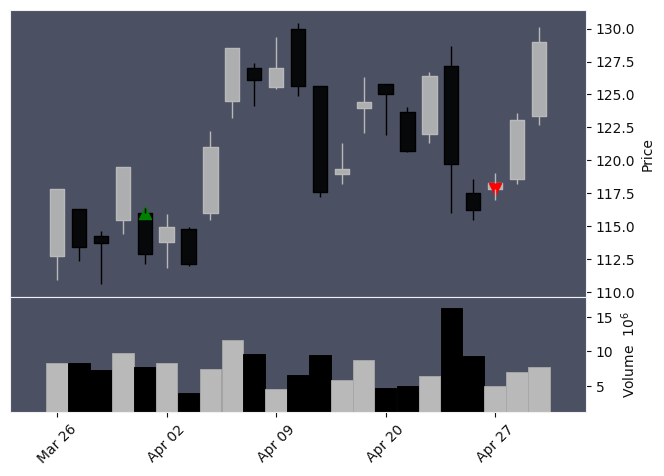


Entry index 82: 129.100, 2020-04-30 00:00:00
Unrealised P/L sequence: [-2.95, -8.75, -5.35, -5.95, -6.85, -2.45, -4.95, -5.4, -10.4, -11.1]
Market to market returns: [-2.29, -4.6, 2.83, -0.48, -0.73, 3.6, -1.97, -0.36, -4.04, -0.59]
Unrealised return sequence: [-2.29, -6.78, -4.14, -4.61, -5.31, -1.9, -3.83, -4.18, -8.06, -8.6]
Exit index 91: 118.000, 2020-05-14 00:00:00
Realised return: -8.60


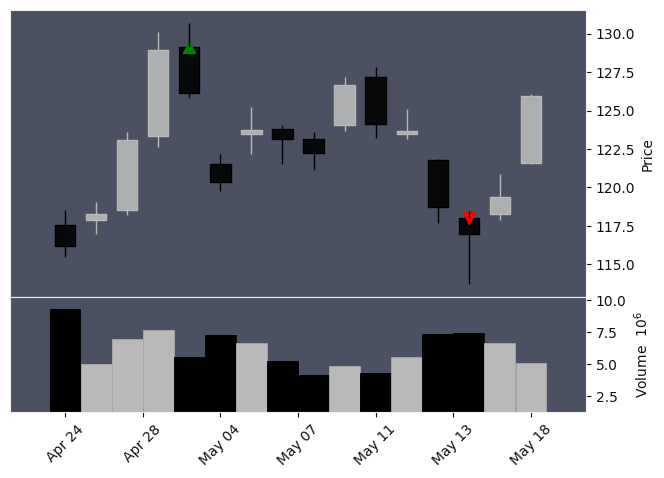


Entry index 95: 126.500, 2020-05-20 00:00:00
Unrealised P/L sequence: [0.65, -1.0, 3.5, 8.25, 10.35, 10.5, 6.75, 11.85, 15.75, 20.7, 21.2, 26.5, 25.9, 23.35, 19.45, 9.7, 10.3, 10.0, 18.85, 21.05, 20.8, 22.8, 22.65, 17.15, 17.15, 17.9, 21.05, 19.4, 20.65, 22.3, 22.3, 26.85, 28.7, 26.8, 25.55, 26.8, 31.5, 30.95, 34.9, 32.25, 33.6, 33.05, 30.9, 33.6, 33.0, 31.15, 32.5, 29.5, 28.5]
Market to market returns: [0.51, -1.3, 3.59, 3.65, 1.56, 0.11, -2.74, 3.83, 2.82, 3.48, 0.34, 3.59, -0.39, -1.67, -2.6, -6.68, 0.44, -0.22, 6.48, 1.51, -0.17, 1.36, -0.1, -3.69, 0.0, 0.52, 2.18, -1.12, 0.86, 1.12, 0.0, 3.06, 1.21, -1.22, -0.82, 0.82, 3.07, -0.35, 2.51, -1.64, 0.85, -0.34, -1.35, 1.72, -0.37, -1.16, 0.86, -1.89, -0.64]
Unrealised return sequence: [0.51, -0.79, 2.77, 6.52, 8.18, 8.3, 5.34, 9.37, 12.45, 16.36, 16.76, 20.95, 20.47, 18.46, 15.38, 7.67, 8.14, 7.91, 14.9, 16.64, 16.44, 18.02, 17.91, 13.56, 13.56, 14.15, 16.64, 15.34, 16.32, 17.63, 17.63, 21.23, 22.69, 21.19, 20.2, 21.19, 24.9, 24.47, 

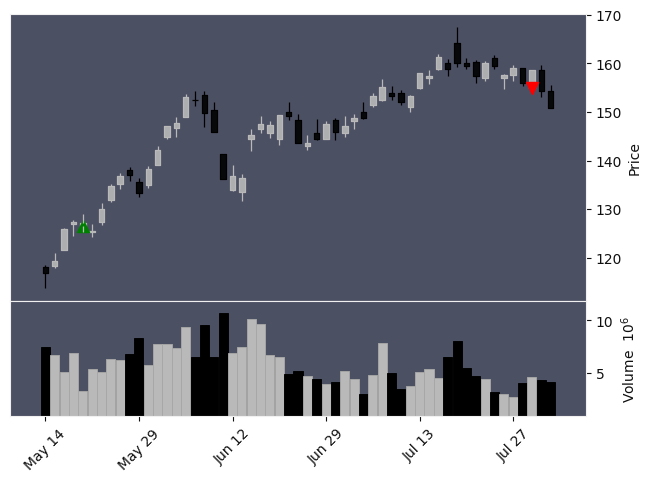


Entry index 152: 161.100, 2020-08-11 00:00:00
Unrealised P/L sequence: [3.1, 2.65, 2.0, -1.85, 1.8, 2.05, 3.9, 0.35, -0.75, 3.35, 1.9, 3.9, 4.55, 4.2, 4.2, 4.05, 6.15, 7.2, 10.05, 10.1, 8.5, 10.6, 11.9, 12.1, 11.05, 9.65, 10.4, 9.4, 9.9, 3.85, 5.0]
Market to market returns: [1.92, -0.27, -0.4, -2.36, 2.29, 0.15, 1.13, -2.15, -0.68, 2.56, -0.88, 1.23, 0.39, -0.21, 0.0, -0.09, 1.27, 0.63, 1.69, 0.03, -0.93, 1.24, 0.76, 0.12, -0.61, -0.81, 0.44, -0.58, 0.29, -3.54, 0.7]
Unrealised return sequence: [1.92, 1.64, 1.24, -1.15, 1.12, 1.27, 2.42, 0.22, -0.47, 2.08, 1.18, 2.42, 2.82, 2.61, 2.61, 2.51, 3.82, 4.47, 6.24, 6.27, 5.28, 6.58, 7.39, 7.51, 6.86, 5.99, 6.46, 5.83, 6.15, 2.39, 3.1]
Exit index 182: 166.100, 2020-09-22 00:00:00
Realised return: 3.10


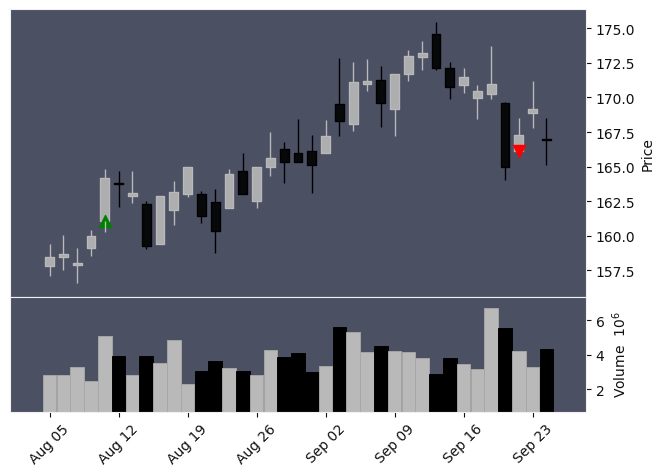


Entry index 187: 174.900, 2020-09-29 00:00:00
Unrealised P/L sequence: [-0.75, -1.85, -0.1, -1.95, 4.95, 4.95, 6.95, 7.8, 5.65, 8.2, 5.9, 6.15, 2.0, 7.85, 10.35, 9.7, 5.05, 7.1, 8.55, 1.9, 2.1]
Market to market returns: [-0.43, -0.63, 1.01, -1.06, 3.99, 0.0, 1.11, 0.47, -1.18, 1.41, -1.26, 0.14, -2.29, 3.31, 1.37, -0.35, -2.52, 1.14, 0.8, -3.62, 0.11]
Unrealised return sequence: [-0.43, -1.06, -0.06, -1.11, 2.83, 2.83, 3.97, 4.46, 3.23, 4.69, 3.37, 3.52, 1.14, 4.49, 5.92, 5.55, 2.89, 4.06, 4.89, 1.09, 1.2]
Exit index 207: 177.000, 2020-10-27 00:00:00
Realised return: 1.20


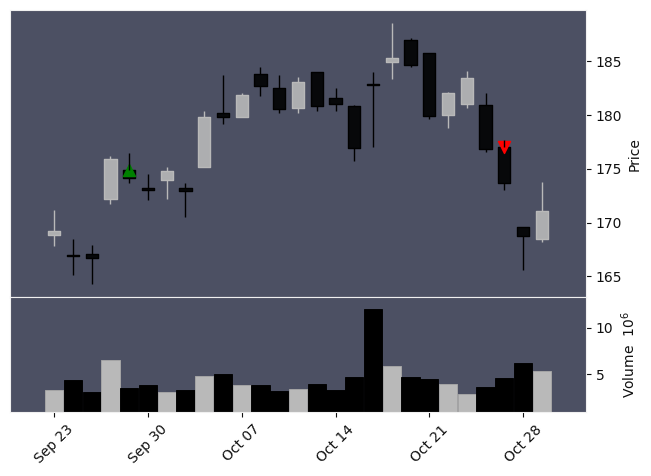


Entry index 214: 185.500, 2020-11-05 00:00:00
Unrealised P/L sequence: [3.65, 4.55, 12.35, 8.2, 6.95, 6.5, 8.5, 13.45, 14.6, 14.7, 14.35, 15.4, 13.95, 17.8, 15.3, 14.1, 14.4, 9.3, 15.0]
Market to market returns: [1.97, 0.48, 4.1, -2.1, -0.65, -0.23, 1.04, 2.55, 0.58, 0.05, -0.17, 0.53, -0.72, 1.93, -1.23, -0.6, 0.15, -2.55, 2.93]
Unrealised return sequence: [1.97, 2.45, 6.66, 4.42, 3.75, 3.5, 4.58, 7.25, 7.87, 7.92, 7.74, 8.3, 7.52, 9.6, 8.25, 7.6, 7.76, 5.01, 8.09]
Exit index 232: 200.500, 2020-12-01 00:00:00
Realised return: 8.09


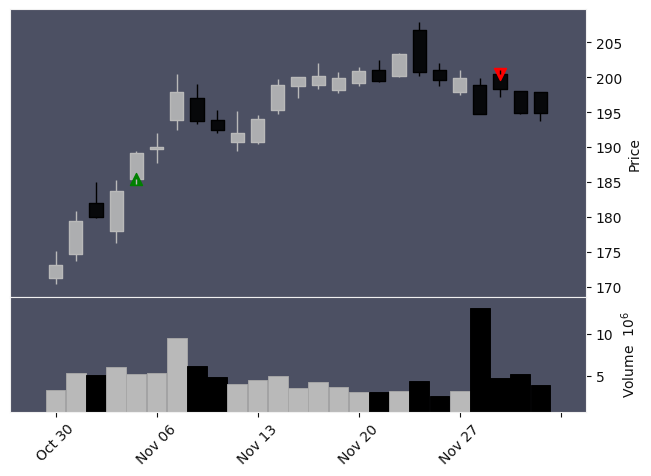


Entry index 243: 197.300, 2020-12-16 00:00:00
Active position
Periods in position: 8
Unrealised return sequence: [-0.38, -0.48, 0.53, -1.88, -1.39, -1.44, -0.81, -0.3]

Ticker: VOLV_B
Performance summary: 
Number of positions: 8
Number of profitable positions: 5
Number of loosing positions: 3
% wins: 62.50
% losses: 37.50
Testing periods: 251
Start capital: 10000
Final capital: 12575.000
Total gross profit: 2575.000
Avg pos net profit: 319.362
Mean P/L: 4.713
Median P/L: 1.975
Std of P/L: 11.330
Mean return: 3.205
Median return: 1.395
Std of returns: 8.535
Expectancy: 8.400
Rate of return: 25.75
Max drawdown: 17.15%
RoMad: 1.501%
Profit factor: 1.858
CAGR: 25.75%
Sharpe ratio: 0.6512
Avg annual profit: 2575.00

Total equity market to market:
[10000.0, 10090.27, 9883.06, 9703.66, 9824.08, 9779.25, 9851.65, 10145.37, 10226.62, 10088.76, 10088.76, 10236.04, 10248.49, 10257.84, 10230.81, 10263.99, 10267.11, 10201.55, 10165.36, 10270.46, 10104.95, 9795.11, 9523.76, 9704.27, 9459.12, 10224.

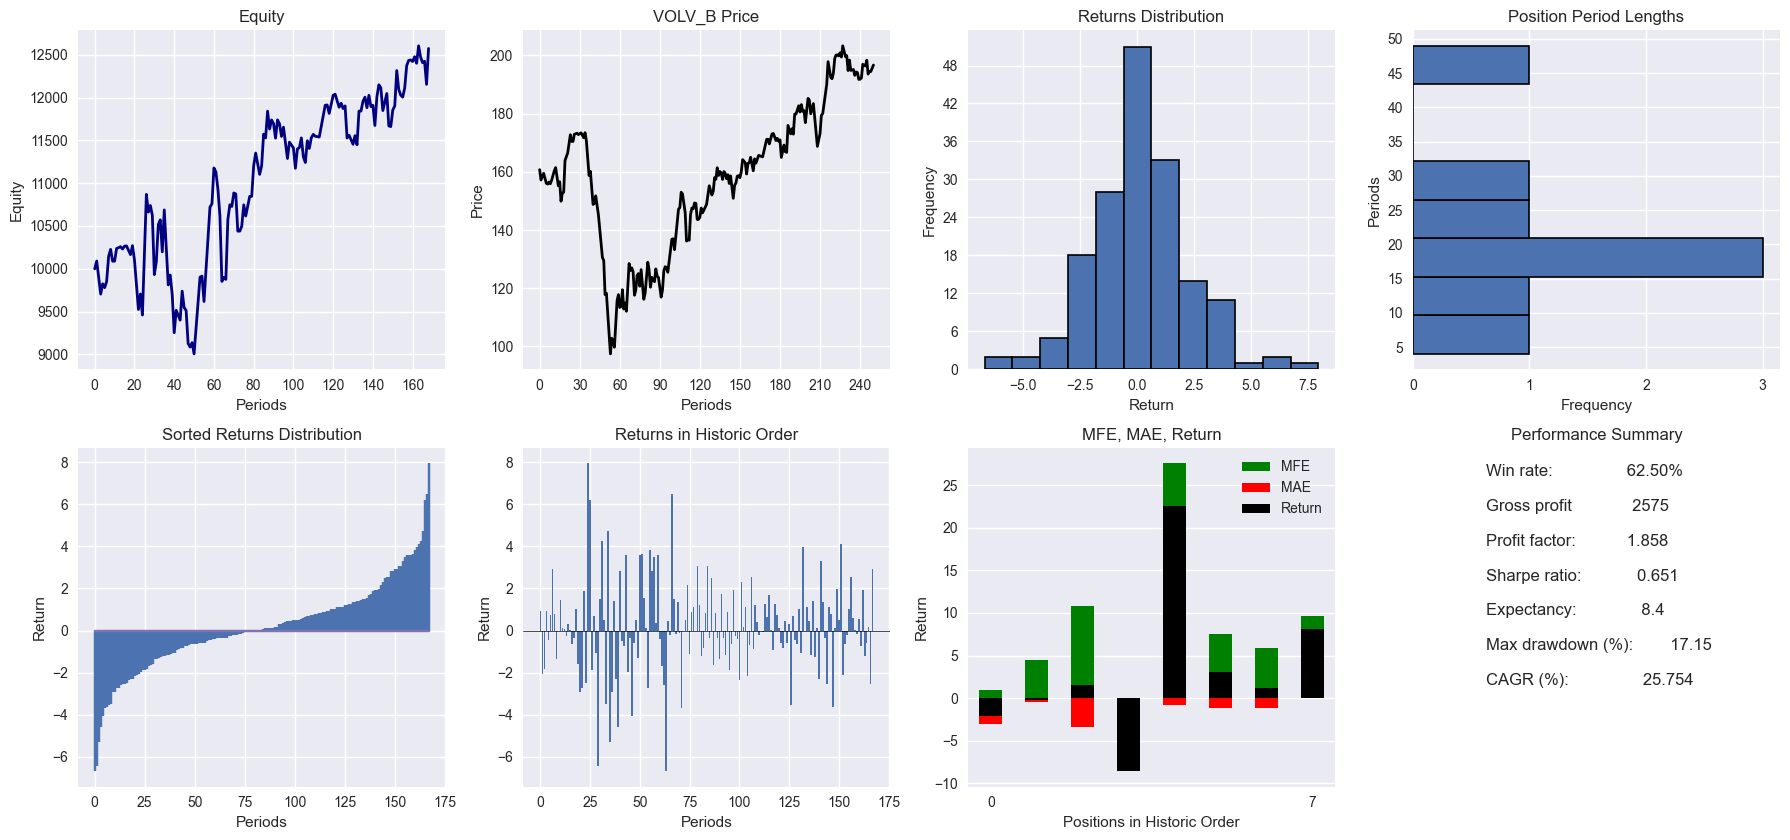


Running Monte Carlo simulations...


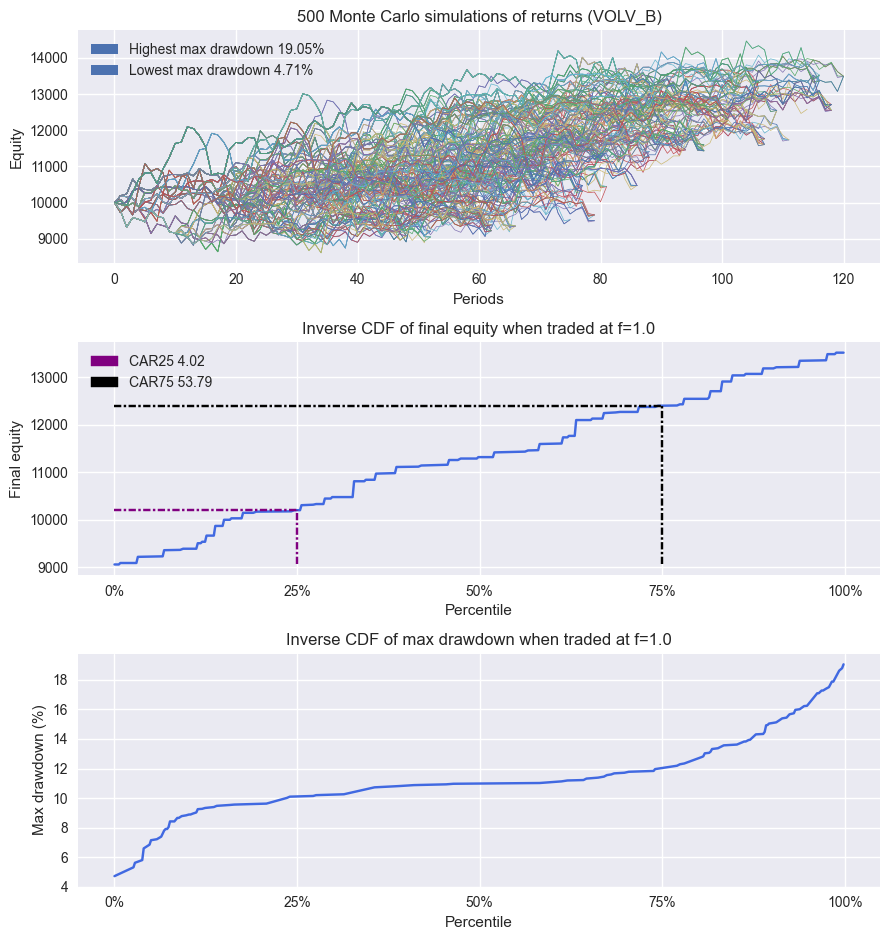


Entry index 14: 318.000, 2020-01-23 00:00:00
Unrealised P/L sequence: [-7.0, 0.5, -4.5, -13.0, -13.0]
Market to market returns: [-2.2, 2.41, -1.57, -2.71, 0.0]
Unrealised return sequence: [-2.2, 0.16, -1.42, -4.09, -4.09]
Exit index 18: 305.000, 2020-01-29 00:00:00
Realised return: -4.09


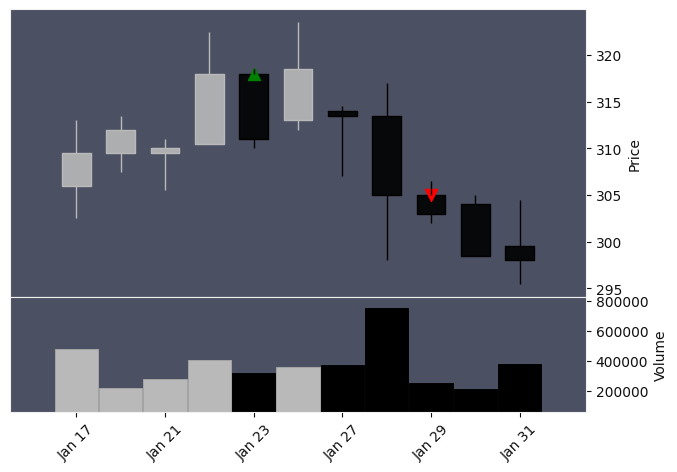


Entry index 27: 318.500, 2020-02-11 00:00:00
Unrealised P/L sequence: [11.0, 59.5, 70.0, 70.0, 82.0, 86.0, 97.5, 100.0, 104.5, 88.5, 78.0, 77.5, 44.0, 20.5]
Market to market returns: [3.45, 14.72, 2.78, 0.0, 3.09, 1.0, 2.84, 0.6, 1.08, -3.78, -2.58, -0.13, -8.46, -6.48]
Unrealised return sequence: [3.45, 18.68, 21.98, 21.98, 25.75, 27.0, 30.61, 31.4, 32.81, 27.79, 24.49, 24.33, 13.81, 6.44]
Exit index 40: 339.000, 2020-02-28 00:00:00
Realised return: 6.44


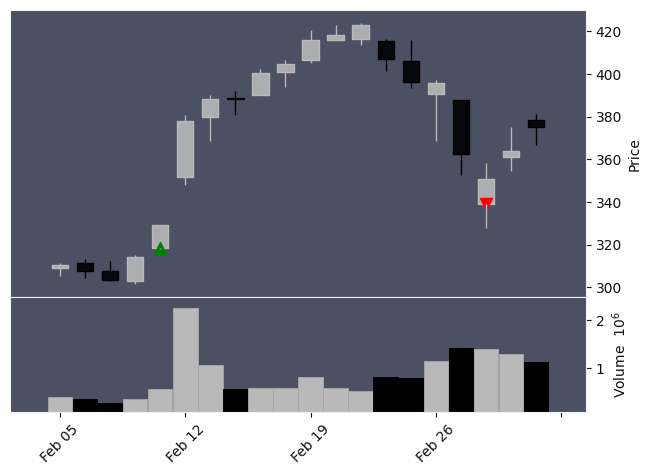


Entry index 62: 346.000, 2020-03-31 00:00:00
Unrealised P/L sequence: [-8.0, -7.7, -21.0, -7.9, 14.6, 35.3, 63.6, 78.0, 112.7, 107.8, 112.2, 135.9, 124.0, 129.9, 132.1, 134.8, 109.0, 123.2, 108.6, 90.5, 89.0]
Market to market returns: [-2.31, 0.09, -3.93, 4.03, 6.65, 5.74, 7.42, 3.52, 8.18, -1.07, 0.97, 5.17, -2.47, 1.26, 0.46, 0.56, -5.37, 3.12, -3.11, -3.98, -0.34]
Unrealised return sequence: [-2.31, -2.23, -6.07, -2.28, 4.22, 10.2, 18.38, 22.54, 32.57, 31.16, 32.43, 39.28, 35.84, 37.54, 38.18, 38.96, 31.5, 35.61, 31.39, 26.16, 25.72]
Exit index 82: 435.000, 2020-04-30 00:00:00
Realised return: 25.72


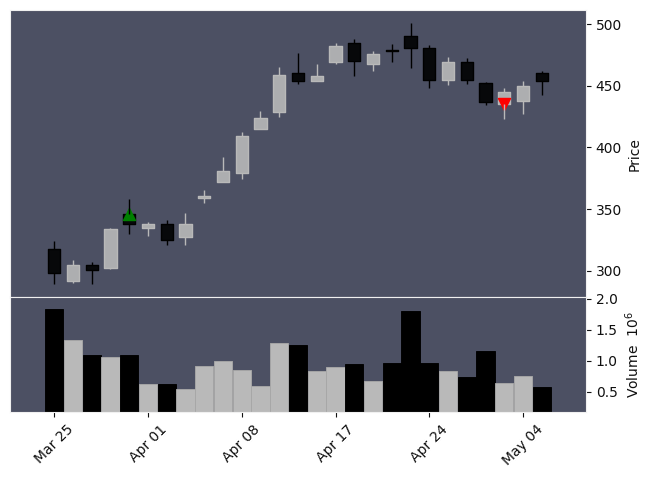


Entry index 88: 496.300, 2020-05-11 00:00:00
Unrealised P/L sequence: [11.7, 1.6, 1.3, -11.3, -4.3, 8.3, 33.9, 30.9, 41.1, 55.7, 69.1, 42.7, 65.3, 59.5, 76.1, 93.9, 104.3, 94.7, 96.9, 80.7, 68.9, 76.1, 66.1, 45.3, 37.5]
Market to market returns: [2.36, -1.99, -0.06, -2.53, 1.44, 2.56, 5.07, -0.57, 1.93, 2.72, 2.43, -4.67, 4.19, -1.03, 2.99, 3.11, 1.76, -1.6, 0.37, -2.73, -2.05, 1.27, -1.75, -3.7, -1.44]
Unrealised return sequence: [2.36, 0.32, 0.26, -2.28, -0.87, 1.67, 6.83, 6.23, 8.28, 11.22, 13.92, 8.6, 13.16, 11.99, 15.33, 18.92, 21.02, 19.08, 19.52, 16.26, 13.88, 15.33, 13.32, 9.13, 7.56]
Exit index 112: 533.800, 2020-06-15 00:00:00
Realised return: 7.56


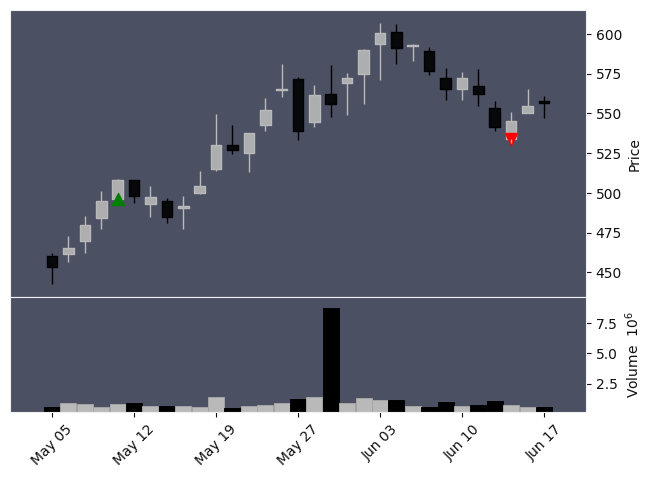


Entry index 117: 600.200, 2020-06-23 00:00:00
Unrealised P/L sequence: [11.8, -24.2, -34.6, -22.6, -40.6, -44.6, 9.8, 30.6, 59.0, 63.8, 77.6, 60.8, 69.2, 62.0, 89.4, 80.0, 69.8, 68.0, 83.8, 94.8, 30.8, 38.6]
Market to market returns: [1.97, -5.88, -1.81, 2.12, -3.12, -0.71, 9.79, 3.41, 4.5, 0.73, 2.08, -2.48, 1.27, -1.08, 4.14, -1.36, -1.5, -0.27, 2.36, 1.61, -9.21, 1.24]
Unrealised return sequence: [1.97, -4.03, -5.76, -3.77, -6.76, -7.43, 1.63, 5.1, 9.83, 10.63, 12.93, 10.13, 11.53, 10.33, 14.9, 13.33, 11.63, 11.33, 13.96, 15.79, 5.13, 6.43]
Exit index 138: 638.800, 2020-07-22 00:00:00
Realised return: 6.43


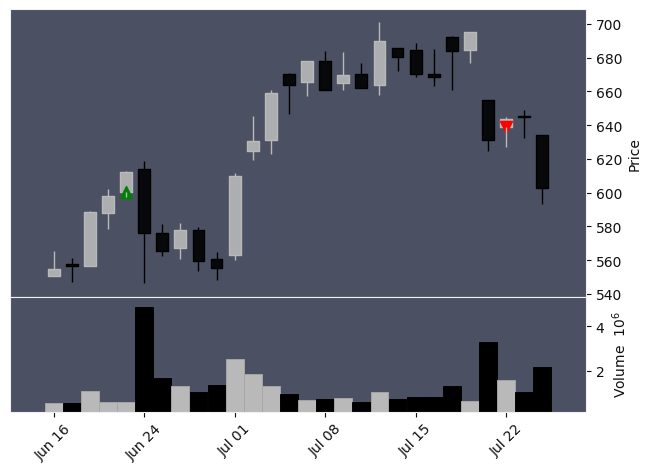


Entry index 161: 638.400, 2020-08-24 00:00:00
Unrealised P/L sequence: [-4.8, 2.6, 11.8, 9.6, 16.0, 9.4, 14.4, -1.4, -38.4, -39.4]
Market to market returns: [-0.75, 1.17, 1.44, -0.34, 0.99, -1.01, 0.77, -2.42, -5.81, -0.17]
Unrealised return sequence: [-0.75, 0.41, 1.85, 1.5, 2.51, 1.47, 2.26, -0.22, -6.02, -6.17]
Exit index 170: 599.000, 2020-09-04 00:00:00
Realised return: -6.17


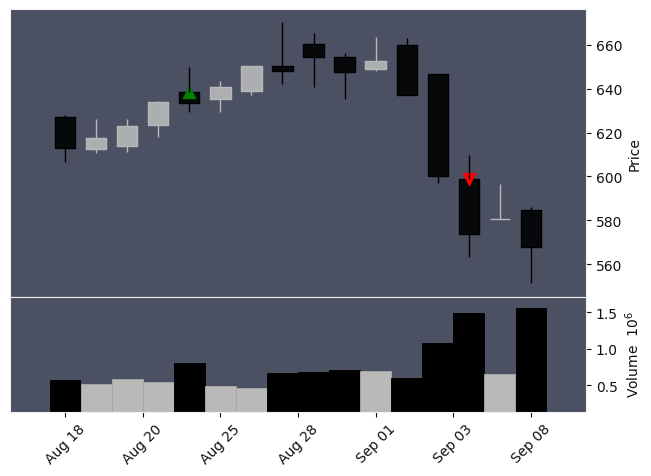


Entry index 181: 591.000, 2020-09-21 00:00:00
Unrealised P/L sequence: [-19.2, -22.6, -22.0, -16.4, -13.0, 13.2, 20.8, 3.8, 27.2, 60.0, 84.0, 75.6, 99.0, 116.2, 165.2, 170.4, 149.0, 138.0, 125.8, 124.2, 117.0, 114.0, 117.8, 103.6, 124.0]
Market to market returns: [-3.25, -0.59, 0.11, 0.98, 0.59, 4.53, 1.26, -2.78, 3.93, 5.31, 3.69, -1.24, 3.51, 2.49, 6.93, 0.69, -2.81, -1.49, -1.67, -0.22, -1.01, -0.42, 0.54, -2.0, 2.94]
Unrealised return sequence: [-3.25, -3.82, -3.72, -2.77, -2.2, 2.23, 3.52, 0.64, 4.6, 10.15, 14.21, 12.79, 16.75, 19.66, 27.95, 28.83, 25.21, 23.35, 21.29, 21.02, 19.8, 19.29, 19.93, 17.53, 20.98]
Exit index 205: 715.000, 2020-10-23 00:00:00
Realised return: 20.98


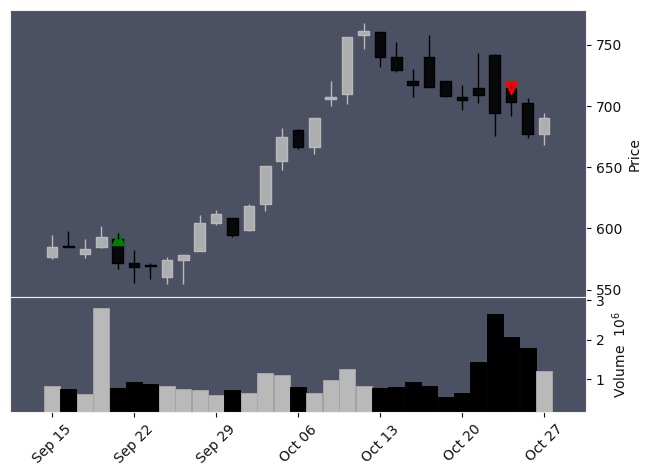


Entry index 216: 730.000, 2020-11-09 00:00:00
Unrealised P/L sequence: [-54.2, -93.0, -94.2]
Market to market returns: [-7.42, -5.74, -0.19]
Unrealised return sequence: [-7.42, -12.74, -12.9]
Exit index 218: 635.800, 2020-11-11 00:00:00
Realised return: -12.90


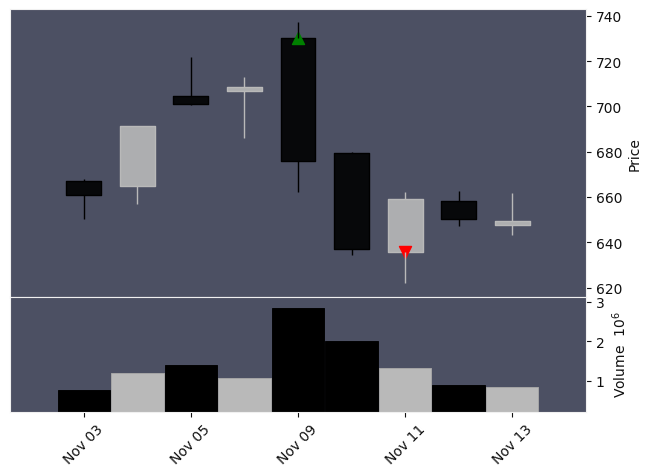


Entry index 231: 697.000, 2020-11-30 00:00:00
Active position
Periods in position: 20
Unrealised return sequence: [5.19, 4.13, 4.73, 8.32, 5.28, 5.28, 8.18, 9.3, 11.62, 13.52, 16.67, 16.21, 14.58, 14.15, 13.52, 11.31, 11.31, 13.63, 18.08, 18.05]

Ticker: EVO
Performance summary: 
Number of positions: 8
Number of profitable positions: 5
Number of loosing positions: 3
% wins: 62.50
% losses: 37.50
Testing periods: 251
Start capital: 10000
Final capital: 16391.000
Total gross profit: 6391.000
Avg pos net profit: 532.562
Mean P/L: 20.375
Median P/L: 29.000
Std of P/L: 65.084
Mean return: 5.496
Median return: 6.435
Std of returns: 12.355
Expectancy: 57.025
Rate of return: 63.91
Max drawdown: 24.10%
RoMad: 2.652%
Profit factor: 2.062
CAGR: 63.92%
Sharpe ratio: 0.9852
Avg annual profit: 6391.00

Total equity market to market:
[10000.0, 9783.12, 10015.47, 9860.46, 9597.09, 9690.81, 10031.45, 11534.97, 11860.72, 11860.72, 12232.86, 12357.02, 12713.15, 12790.52, 12930.63, 12434.95, 12109.42, 12

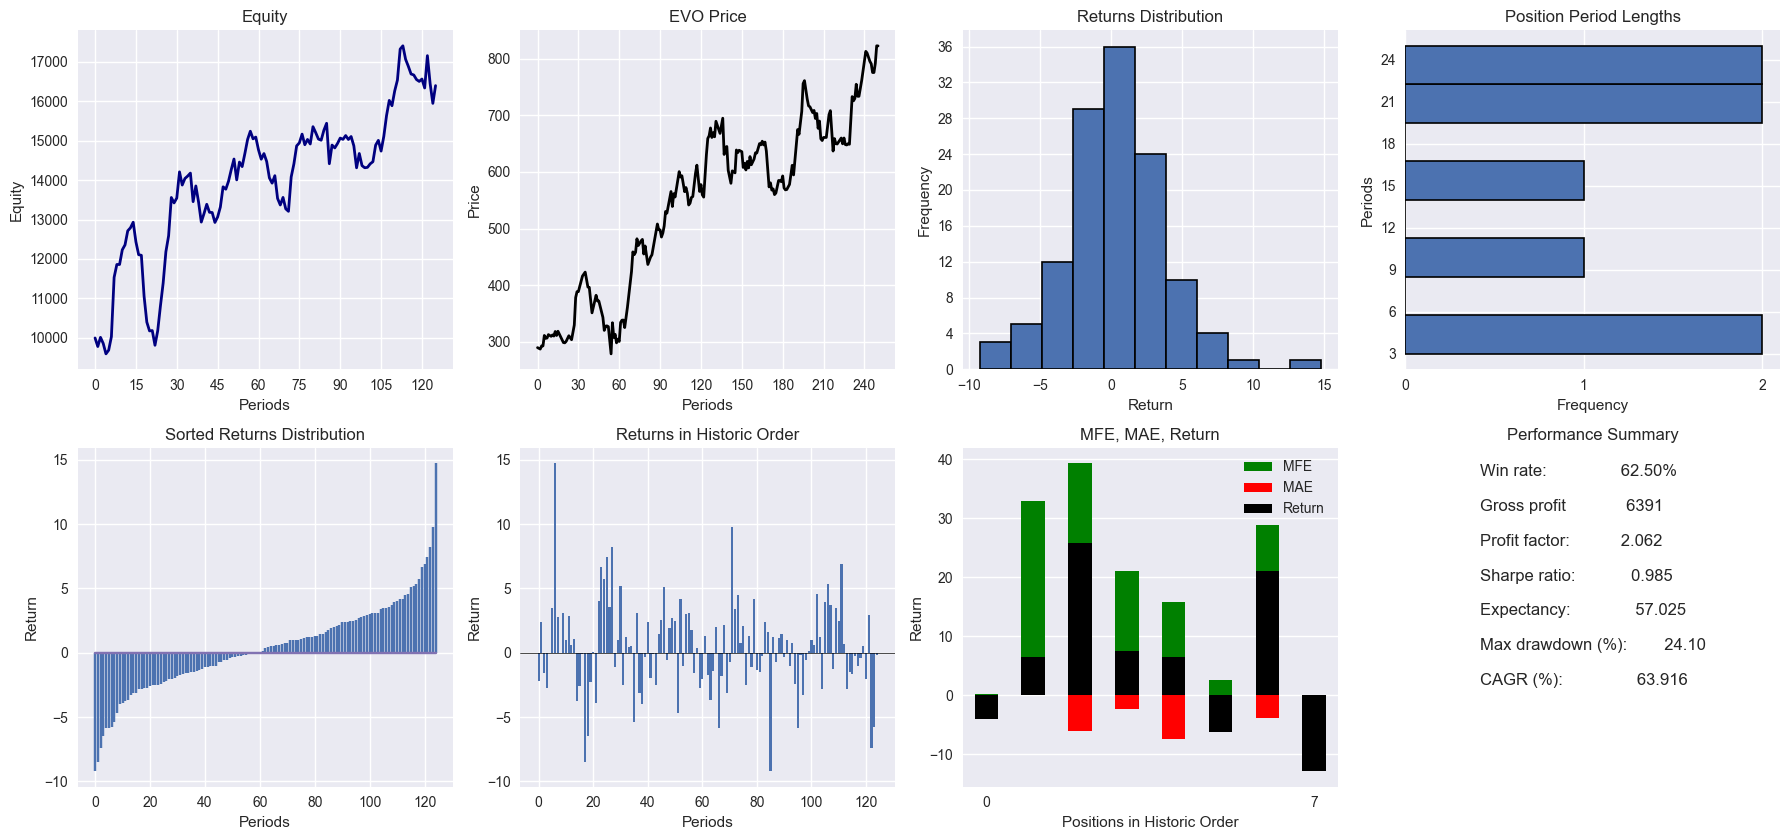


Running Monte Carlo simulations...


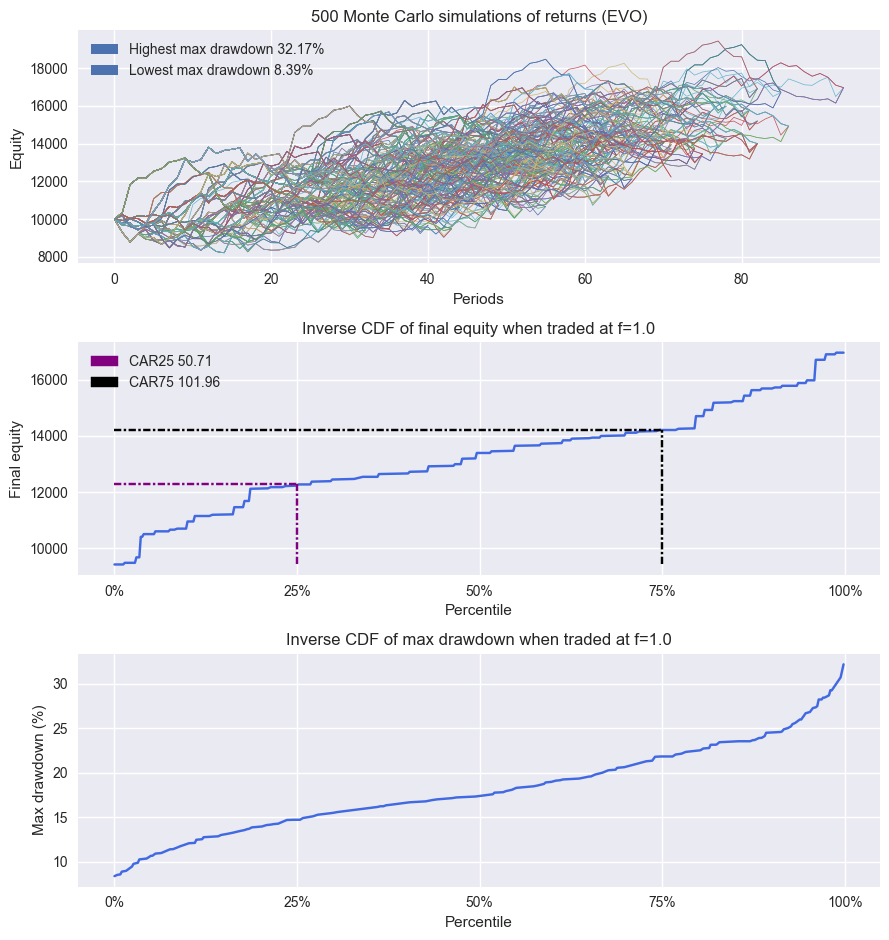


Strategy performance summary: 
    Ticker Number of positions Start capital Final capital Total gross profit Avg pos net profit     % wins Profit factor  Sharpe ratio  Rate of return  Mean P/L  Median P/L  Std of P/L  Mean return  Median return  Std of returns  Expectancy  Avg MAE  Min MAE  Avg MFE  Max MFE  Max drawdown (%)  RoMad  CAGR (%)
0  ATCO_A                   7         10000         12763               2763            245.257  57.142857         1.490         0.443           27.63     8.200      15.500      24.100        2.517          3.850           6.564      22.257   -2.470    -4.64    9.013    23.20         14.422730  1.916    27.631
1  ERIC_B                   8         10000          9355               -645            -86.375  37.500000         0.636        -0.379           -6.45    -0.882      -0.740       3.208       -0.872         -0.865           3.301       2.697   -3.334    -9.03    5.870    11.89         19.534145 -0.330    -6.449
2  VOLV_B                   8  

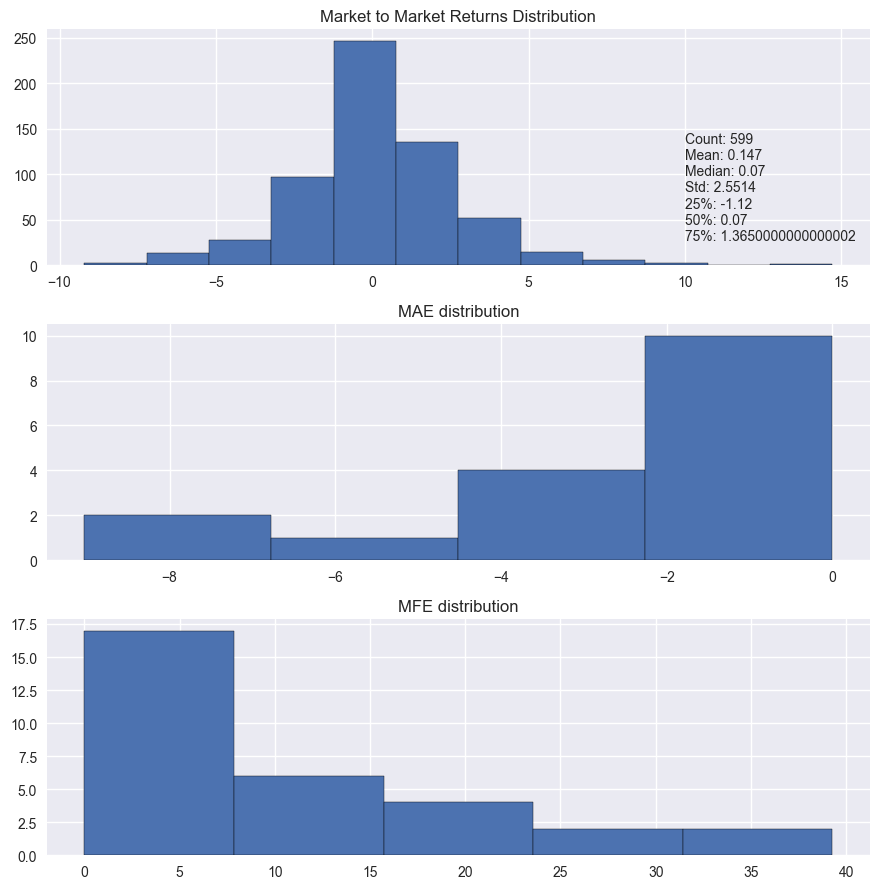

In [7]:
ts = TradingSystem(df_dict, strategy_function, entry_logic_test, exit_logic_test, pos_sizer)
ts(
    capital=10000,
    capital_fraction=1.0,
    plot_performance_summary=True,
    save_summary_plot_to_path=None,
    system_analysis_to_csv_path=None,
    plot_returns_distribution=True,
    save_returns_distribution_plot_to_path=None,
    run_monte_carlo_sims=True,
    num_of_monte_carlo_sims=500,
    monte_carlo_data_amount=0.5,
    plot_monte_carlo=True,
    print_monte_carlo_df=False,
    monte_carlo_analysis_to_csv_path=None,
    entry_args={'entry_param_period': 10},
    exit_args={'exit_param_period': 10},
    fixed_position_size=True,
    commission_pct_cost=0.0025,
    generate_signals=True,
    plot_positions=True,
    save_position_figs_path=None
)